<a href="https://colab.research.google.com/github/DaviTeobaldo/Curso-Intensivo-de-Computacao-Quantica/blob/main/Aula_pratica_curso_imersivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computação Quântica com Qiskit

## Operadores unitários, representação de estados e medição quântica

Este notebook apresenta uma introdução prática à Computação Quântica utilizando o framework **Qiskit**, enfatizando a relação entre a formulação matemática da Mecânica Quântica e sua implementação computacional.

Ao longo das atividades serão explorados:

- Representação vetorial de qubits;
- Evolução temporal por operadores unitários;
- Construção de circuitos quânticos;
- Simulação clássica da dinâmica quântica;
- Interpretação probabilística do processo de medição.

Sempre que possível, os resultados obtidos pelo simulador serão interpretados analiticamente a partir da Álgebra Linear subjacente ao formalismo quântico.

## 1. Instalação

Antes da construção dos circuitos, é necessário instalar as bibliotecas responsáveis pela simulação e execução dos algoritmos quânticos.

- **qiskit**: biblioteca principal para construção e manipulação de circuitos quânticos;
- **qiskit-aer**: simulador clássico capaz de reproduzir a evolução de sistemas quânticos;
- **qiskit_ibm_runtime**: interface para execução de circuitos em computadores quânticos disponibilizados pela IBM;
- **pylatexenc**: renderização de expressões matemáticas em LaTeX durante a visualização dos circuitos.

In [ ]:
!pip -q install qiskit qiskit-aer qiskit_ibm_runtime pylatexenc
import qiskit
print(qiskit.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━

## 2. Importações

As principais estruturas empregadas neste notebook são:

- `QuantumCircuit`: modela matematicamente um circuito quântico, permitindo a aplicação sucessiva de operadores unitários sobre os qubits.

- `Statevector`: representa exatamente o vetor de estado do sistema antes da realização de qualquer medição.

- `AerSimulator`: simula computacionalmente a evolução do circuito utilizando métodos clássicos.

- `plot_histogram`: apresenta experimentalmente a distribuição de probabilidades obtida após múltiplas medições.

- `plot_bloch_multivector`: representa geometricamente estados de um único qubit por meio da Esfera de Bloch.

Essas ferramentas permitem analisar simultaneamente a descrição algébrica, geométrica e probabilística de um sistema quântico.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit import transpile


## 3. Hadamard em |0⟩

A porta Hadamard $H$ é a porta que cria **superposição**. Aplicada a $|0\rangle$, ela produz:

$$H|0\rangle = \frac{1}{\sqrt{2}}\big(|0\rangle + |1\rangle\big) = |+\rangle$$

Fisicamente, isso corresponde a uma rotação de 90° em torno do eixo Y (seguida de uma rotação em torno do eixo X, ou equivalentemente uma reflexão), levando o vetor de Bloch do polo norte ($|0\rangle$) para o equador, na direção $+X$.

**O que observar nos resultados abaixo:**
- O vetor de estado terá amplitudes iguais $\frac{1}{\sqrt{2}}$ para $|0\rangle$ e $|1\rangle$, ambas com fase positiva.
- Na esfera de Bloch, o vetor deve apontar para o eixo $+X$ (equador), não para os polos — isso é a assinatura visual de uma superposição igualitária.
- No histograma, esperamos aproximadamente 50% de contagens em `0` e 50% em `1`, já que a medição na base computacional projeta o estado sobre um dos polos com probabilidade $|\langle 0|+\rangle|^2 = |\langle 1|+\rangle|^2 = 1/2$.

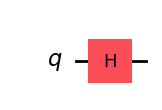

<IPython.core.display.Latex object>

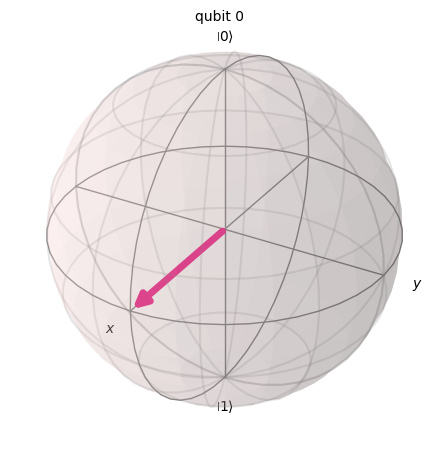

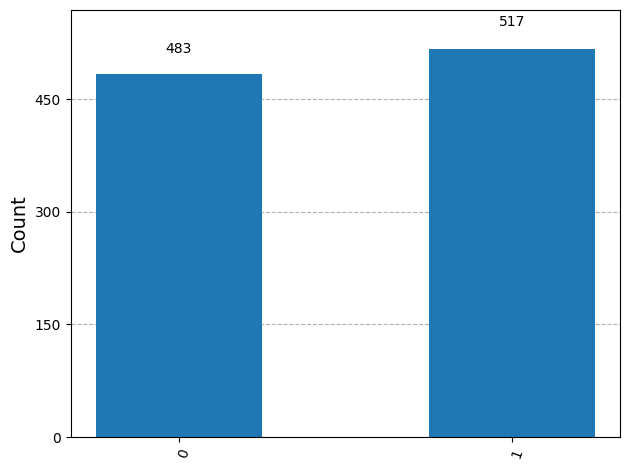

In [ ]:
qc=QuantumCircuit(1)
qc.h(0)
display(qc.draw('mpl'))
sv=Statevector.from_instruction(qc)
display(sv.draw('latex'))
display(plot_bloch_multivector(sv))
m=qc.copy();m.measure_all()
sim=AerSimulator()
res=sim.run(transpile(m,sim),shots=1000).result()
display(plot_histogram(res.get_counts()))

## 4. Hadamard em |1⟩

Agora partimos de $|1\rangle$ (obtido aplicando uma porta $X$, que é o análogo quântico da porta NOT clássica, a $|0\rangle$) e aplicamos $H$:

$$H|1\rangle = \frac{1}{\sqrt{2}}\big(|0\rangle - |1\rangle\big) = |-\rangle$$

A diferença crucial em relação ao caso anterior é o **sinal relativo** entre as amplitudes: aqui temos um sinal negativo diante de $|1\rangle$. Essa fase relativa não é visível na medição direta (o histograma de contagens continuará ~50/50), mas é visível:
- Na representação LaTeX do `Statevector` (o sinal de menos aparece explicitamente).
- Na esfera de Bloch, onde o vetor aponta para $-X$ em vez de $+X$.

Consequentemente, estados distintos podem produzir a mesma distribuição de probabilidades caso possuam fases relativas diferentes. Essa propriedade constitui o principal mecanismo explorado pelos algoritmos quânticos baseados em interferência.

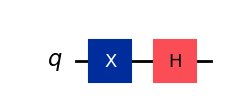

<IPython.core.display.Latex object>

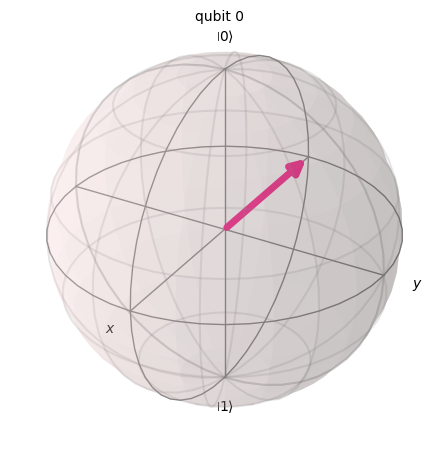

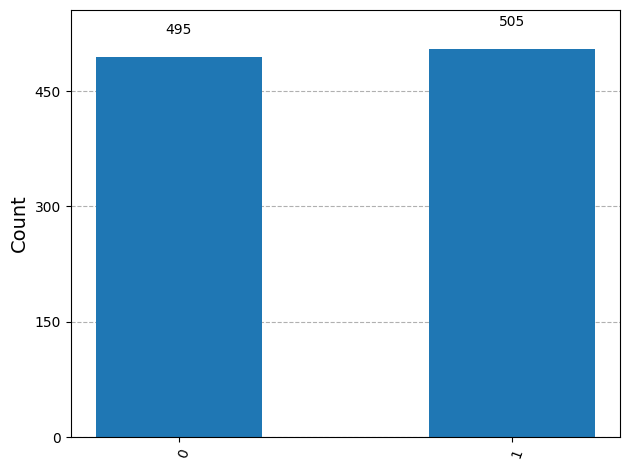

In [ ]:
qc=QuantumCircuit(1)
qc.x(0);qc.h(0)
display(qc.draw('mpl'))
sv=Statevector.from_instruction(qc)
display(sv.draw('latex'))
display(plot_bloch_multivector(sv))
m=qc.copy();m.measure_all()
sim=AerSimulator()
res=sim.run(transpile(m,sim),shots=1000).result()
display(plot_histogram(res.get_counts()))

## 5. Verificando H² = I

Toda porta quântica é uma operação **unitária e reversível** — isso reflete o fato de que a evolução de um sistema quântico fechado é regida pela equação de Schrödinger, que preserva a norma do vetor de estado. Uma consequência direta é que muitas portas são suas próprias inversas.

Para a Hadamard, isso significa:

$$H^2 = I \quad \Longrightarrow \quad H(H|\psi\rangle) = |\psi\rangle$$

Pode-se verificar isso diretamente: aplicando $H$ duas vezes sobre $|0\rangle$ devemos recuperar exatamente $|0\rangle$, e o mesmo para $|1\rangle$. É a interferência entre as duas amplitudes geradas pela primeira Hadamard que "desfaz" a superposição na segunda aplicação — um exemplo simples, mas poderoso, de interferência construtiva e destrutiva em ação.

Estado inicial 0


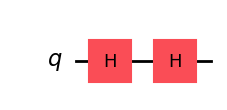

<IPython.core.display.Latex object>

Estado inicial 1


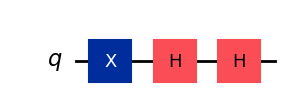

<IPython.core.display.Latex object>

In [ ]:
for init in [0,1]:
    qc=QuantumCircuit(1)
    if init: qc.x(0)
    qc.h(0);qc.h(0)
    print("Estado inicial",init)
    display(qc.draw('mpl'))
    display(Statevector.from_instruction(qc).draw('latex'))

## 6. Verificando que CNOT é sua própria inversa

Assim como fizemos com a Hadamard na Seção 5, pode-se confirmar numericamente uma propriedade que usamos na Seção sobre Superdense Coding: a porta **CNOT também é sua própria inversa**.

$$\text{CNOT}_{0\to1}\cdot\text{CNOT}_{0\to1} = I$$

Isso vale porque CNOT é hermitiana e unitária ao mesmo tempo (como toda porta reversível de base computacional): ela troca o estado do alvo quando o controle é $|1\rangle$, e aplicá-la duas vezes seguidas troca o alvo, depois troca de volta — voltando ao estado original.

**O que testar:** para cada um dos quatro estados da base computacional de 2 qubits ($|00\rangle,|01\rangle,|10\rangle,|11\rangle$), vamos preparar o estado, aplicar CNOT duas vezes (controle em q0, alvo em q1) e verificar que recuperamos exatamente o estado inicial — tanto olhando o circuito quanto o vetor de estado resultante.

Estado inicial: |00>


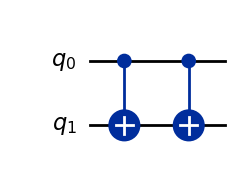

<IPython.core.display.Latex object>

Estado inicial: |01>


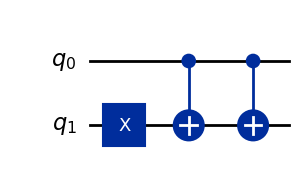

<IPython.core.display.Latex object>

Estado inicial: |10>


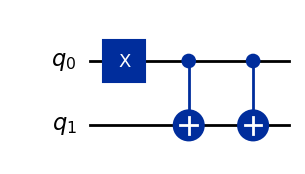

<IPython.core.display.Latex object>

Estado inicial: |11>


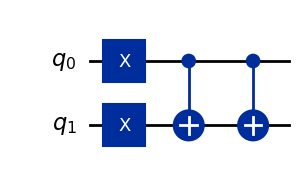

<IPython.core.display.Latex object>

In [ ]:
for b0, b1 in [(0,0),(0,1),(1,0),(1,1)]:
    qc = QuantumCircuit(2)
    if b0: qc.x(0)
    if b1: qc.x(1)
    qc.cx(0,1); qc.cx(0,1)
    print(f"Estado inicial: |{b0}{b1}>")
    display(qc.draw('mpl'))
    display(Statevector.from_instruction(qc).draw('latex'))

Repare que, em todos os casos, o estado final coincide exatamente com o estado inicial — confirmando $\text{CNOT}^2=I$. É essa propriedade, junto com $H^2=I$ (Seção 5), que garante que o circuito de decodificação do Superdense Coding (CNOT + H) realmente desfaz o circuito de preparação do par de Bell (H + CNOT), como discutimos mais adiante.

## 7. Estado de Bell |Φ+⟩

Agora entramos no território que separa a computação quântica da computação clássica: o **emaranhamento**.

O circuito abaixo aplica uma Hadamard no qubit 0 (criando superposição) e, em seguida, uma porta CNOT (`cx`) controlada por q0 e alvo em q1. O resultado é:

$$|00\rangle \xrightarrow{H \otimes I} \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle) \xrightarrow{\text{CNOT}} \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) = |\Phi^+\rangle$$

Esse é um dos quatro **estados de Bell**, a base de estados maximamente emaranhados de dois qubits. A característica física central é que $|\Phi^+\rangle$ **não pode ser escrito como um produto tensorial** de estados individuais de q0 e q1 — não existe $|\psi_0\rangle$ e $|\psi_1\rangle$ tais que $|\Phi^+\rangle = |\psi_0\rangle \otimes |\psi_1\rangle$.

**Consequência mensurável:** ao medir os dois qubits, os resultados serão sempre **perfeitamente correlacionados** — obtemos `00` ou `11`, nunca `01` ou `10`, cada um com probabilidade próxima de 50%. Isso ocorre mesmo que, individualmente, cada qubit pareça "aleatório" quando medido sozinho.

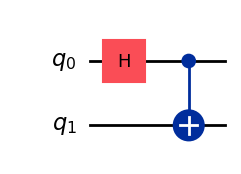

<IPython.core.display.Latex object>

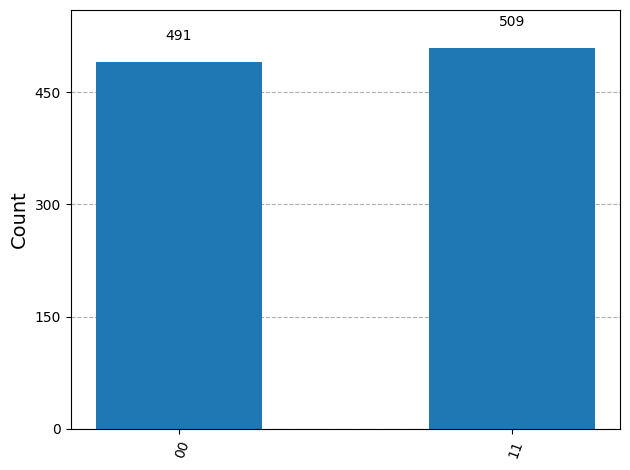

In [ ]:
qc=QuantumCircuit(2)
qc.h(0);qc.cx(0,1)
display(qc.draw('mpl'))
sv=Statevector.from_instruction(qc)
display(sv.draw('latex'))
m=qc.copy();m.measure_all()
sim=AerSimulator()
res=sim.run(transpile(m,sim),shots=1000).result()
display(plot_histogram(res.get_counts()))

## 8. Os quatro estados de Bell

Os quatro estados de Bell formam uma base ortonormal completa para o espaço de dois qubits e são obtidos a partir do mesmo circuito base (H + CNOT), aplicando portas adicionais de correção de fase e de bit antes da Hadamard:

| Estado | Circuito adicional | Expressão |
|---|---|---|
| $\|\Phi^+\rangle$ | nenhuma porta extra | $\frac{1}{\sqrt{2}}(\|00\rangle+\|11\rangle)$ |
| $\|\Phi^-\rangle$ | $Z$ em q0 | $\frac{1}{\sqrt{2}}(\|00\rangle-\|11\rangle)$ |
| $\|\Psi^+\rangle$ | $X$ em q0 | $\frac{1}{\sqrt{2}}(\|01\rangle+\|10\rangle)$ |
| $\|\Psi^-\rangle$ | $X$ e $Z$ em q0 | $\frac{1}{\sqrt{2}}(\|01\rangle-\|10\rangle)$ |

Note o padrão: $X$ troca qual par de resultados aparece correlacionado (`00`/`11` vira `01`/`10`), enquanto $Z$ apenas introduz um sinal relativo (fase) entre as duas parcelas, sem alterar as probabilidades de medição na base computacional. Essa distinção entre **erro de bit** ($X$) e **erro de fase** ($Z$) é exatamente o vocabulário que reaparece mais tarde em correção de erros quânticos.

Phi+


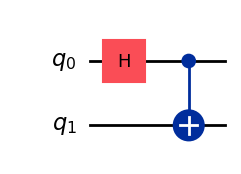

<IPython.core.display.Latex object>

Phi-


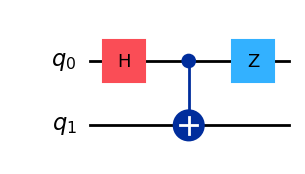

<IPython.core.display.Latex object>

Psi+


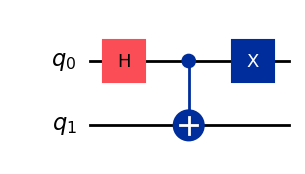

<IPython.core.display.Latex object>

Psi-


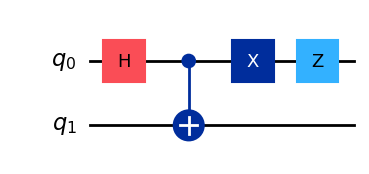

<IPython.core.display.Latex object>

In [ ]:
def bell(i):
 q=QuantumCircuit(2)
 q.h(0);q.cx(0,1)
 if i=='Phi-': q.z(0)
 elif i=='Psi+': q.x(0)
 elif i=='Psi-': q.x(0);q.z(0)
 return q
for name in ['Phi+','Phi-','Psi+','Psi-']:
    qc=bell(name)
    print(name)
    display(qc.draw('mpl'))
    display(Statevector.from_instruction(qc).draw('latex'))

## 9. Superdense Coding

**Superdense Coding** é um protocolo que usa um par de qubits previamente emaranhados para transmitir **2 bits clássicos de informação enviando apenas 1 qubit**. É o "espelho" do teleporte quântico: lá se usa emaranhamento + 2 bits clássicos para transmitir 1 qubit; aqui se usa emaranhamento + 1 qubit para transmitir 2 bits clássicos.

**Ideia do protocolo:**

1. Alice e Bob compartilham previamente um par de qubits no estado de Bell $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$ (q0 fica com Alice, q1 com Bob).
2. Alice quer enviar uma mensagem de 2 bits $(b_1 b_0)$. Ela aplica portas **apenas no seu próprio qubit (q0)**, de acordo com a tabela:

| Mensagem | Porta em q0 | Estado resultante |
|---|---|---|
| `00` | nenhuma | $\|\Phi^+\rangle$ |
| `01` | $X$ | $\|\Psi^+\rangle$ |
| `10` | $Z$ | $\|\Phi^-\rangle$ |
| `11` | $X$ então $Z$ | $\|\Psi^-\rangle$ |

3. Alice envia fisicamente **apenas o seu qubit** (q0) para Bob. Ele agora possui os dois qubits.
4. Bob aplica CNOT (q0 controla q1) seguido de Hadamard em q0 — o inverso do circuito que preparou o estado de Bell — e mede os dois qubits na base computacional. O resultado da medição reproduz exatamente os 2 bits que Alice queria enviar.

**Por que isso é notável:** apenas 1 qubit físico trafegou entre Alice e Bob no passo 3, mas 2 bits clássicos de informação foram transmitidos. O "custo" foi pago antecipadamente, na distribuição do emaranhamento — o que ilustra o emaranhamento como um **recurso** que pode ser consumido para ganhar capacidade de comunicação.

No código abaixo, para cada mensagem observe que o histograma de medição concentra praticamente 100% das contagens exatamente na string binária da mensagem original (lembrando que o Qiskit ordena os bits de medição com o qubit mais significativo à esquerda).

### Por que a decodificação de Bob usa a *mesma* CNOT (e não a invertida)?

Um erro de intuição comum: ao ver o circuito de decodificação (CNOT seguida de H), muita gente espera que a CNOT devesse "inverter a direção" (controle e alvo trocados) para desfazer o que foi feito na preparação. Isso não é necessário, e vale entender por quê — é um exercício direto de como inverter um circuito quântico.

**A preparação do par de Bell é:**

$$U = \text{CNOT}_{0\to1}\cdot(H\otimes I)$$

(lendo da direita para a esquerda: primeiro $H$ em q0, depois CNOT controlado por q0 com alvo em q1)

**Para desfazer, Bob precisa aplicar $U^\dagger$.** A regra geral para inverter uma sequência de portas é: inverter cada porta individualmente **e** inverter a ordem em que são aplicadas:

$$U^\dagger = (H\otimes I)^\dagger \cdot (\text{CNOT}_{0\to1})^\dagger$$

Aqui entra o ponto chave: tanto $H$ quanto CNOT são **hermitianas e unitárias ao mesmo tempo**, o que as torna suas próprias inversas:

$$H^\dagger = H, \qquad \text{CNOT}_{0\to1}^{\dagger} = \text{CNOT}_{0\to1}$$

Ou seja, "desfazer" uma CNOT com controle em q0 é aplicar de novo essa *mesma* CNOT (controle em q0, alvo em q1) — não trocar quem é controle e quem é alvo. Substituindo:

$$U^\dagger = (H\otimes I)\cdot \text{CNOT}_{0\to1}$$

Que é exatamente: **primeiro CNOT (controle q0, alvo q1), depois H em q0** — a mesma direção de CNOT, só com a *ordem* das duas portas invertida em relação à preparação. É isso que o circuito de decodificação faz.

**Por que isso funciona fisicamente:** a CNOT é uma porta involutória — aplicá-la duas vezes seguidas na mesma direção equivale à identidade ($\text{CNOT}_{0\to1}\cdot\text{CNOT}_{0\to1} = I$). O mesmo vale para $H$ ($H^2=I$, como vimos na Seção 5). Por isso, ao empilhar CNOT + H (decodificação) depois de H + CNOT (codificação), tudo se cancela na ordem certa e o par de Bell original é desfeito, revelando os dois bits clássicos na base computacional.

**Teste você mesmo:** troque, na função `superdense()`, a linha `qc.cx(0,1)` do trecho de decodificação por `qc.cx(1,0)` (controle e alvo invertidos) e rode novamente. O histograma deixará de bater com a mensagem original — a prova de que a direção da CNOT importa, e de que a direção correta é a mesma da preparação, não a invertida.

Mensagem: 00


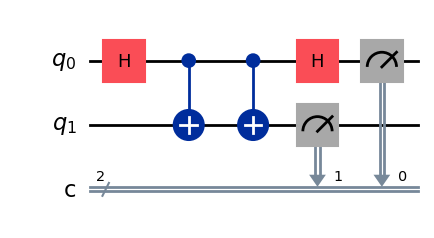

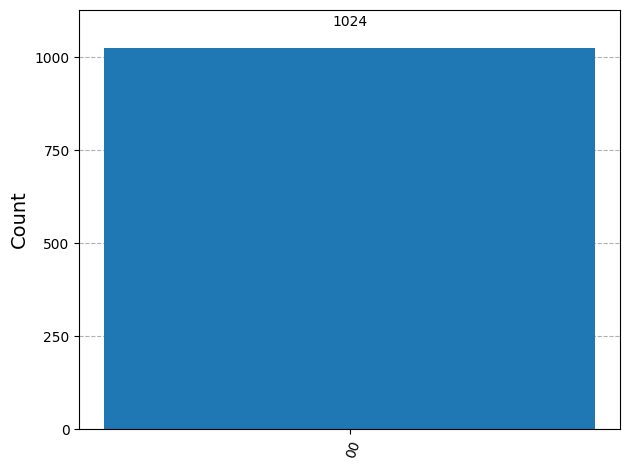

Mensagem: 01


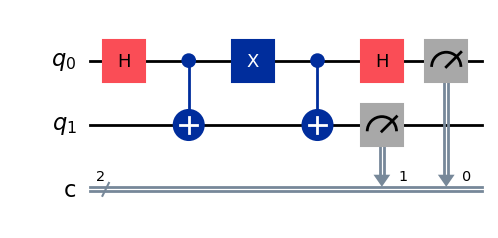

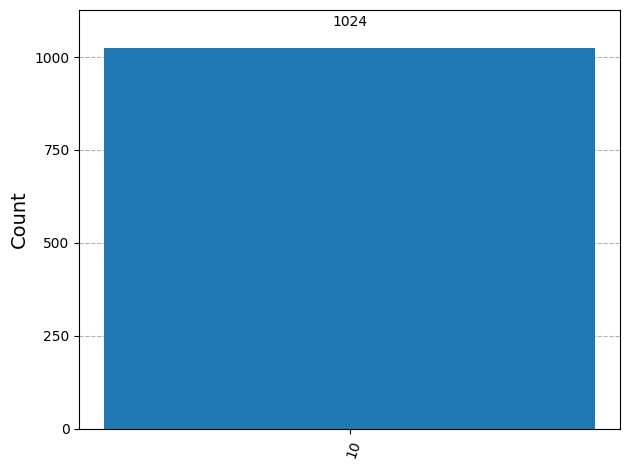

Mensagem: 10


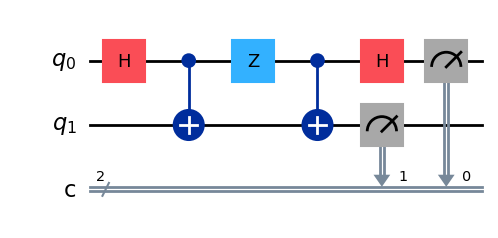

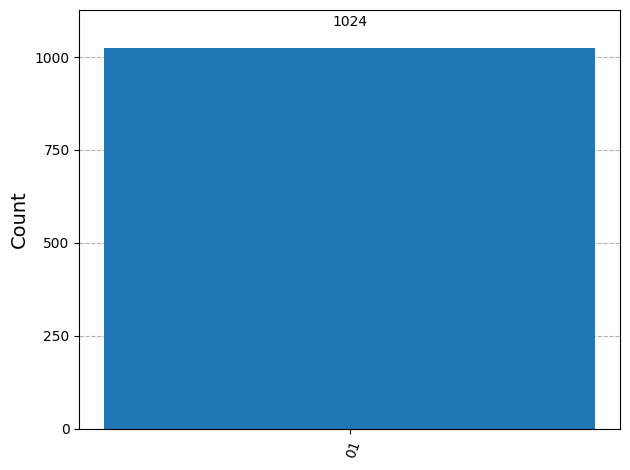

Mensagem: 11


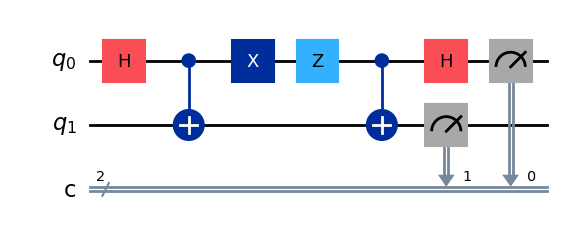

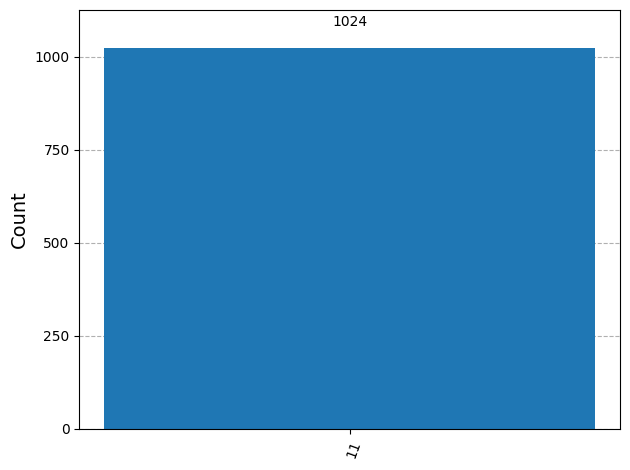

In [ ]:
def superdense(msg):
    qc=QuantumCircuit(2,2)
    qc.h(0);qc.cx(0,1)
    if msg=='01': qc.x(0)
    elif msg=='10': qc.z(0)
    elif msg=='11':
        qc.x(0);qc.z(0)
    qc.cx(0,1);qc.h(0)
    qc.measure([0,1],[0,1])
    sim=AerSimulator()
    res=sim.run(transpile(qc,sim),shots=1024).result()
    print("Mensagem:",msg)
    display(qc.draw('mpl'))
    display(plot_histogram(res.get_counts()))
for m in ['00','01','10','11']:
    superdense(m)


### Diagrama esquemático do protocolo

A célula a seguir gera um diagrama simples (com `matplotlib`, sem depender de nenhuma imagem externa) mostrando o fluxo de Alice e Bob no Superdense Coding: preparação do par emaranhado, operação local de Alice, envio de um único qubit, e decodificação de Bob.

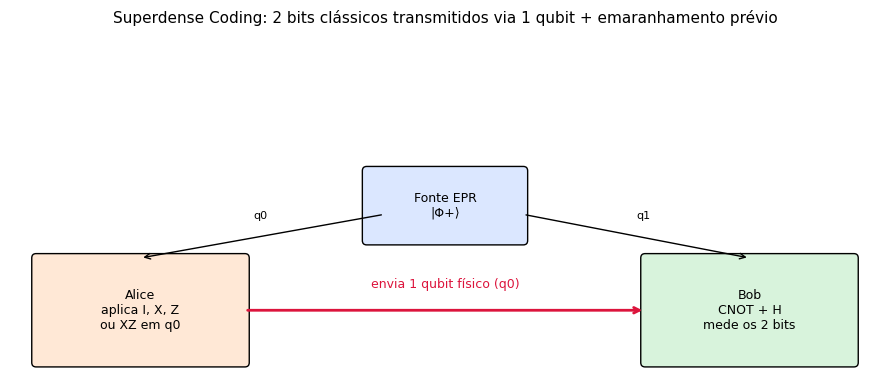

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9,4))
ax.set_xlim(0,10); ax.set_ylim(0,4); ax.axis('off')

# Fonte do par emaranhado
ax.add_patch(mpatches.FancyBboxPatch((4.1,1.6),1.8,0.8, boxstyle="round,pad=0.05", fc="#dbe7ff", ec="black"))
ax.text(5,2.0,"Fonte EPR\n|Φ+⟩",ha='center',va='center',fontsize=9)

# Alice
ax.add_patch(mpatches.FancyBboxPatch((0.3,0.2),2.4,1.2, boxstyle="round,pad=0.05", fc="#ffe8d6", ec="black"))
ax.text(1.5,0.8,"Alice\naplica I, X, Z\nou XZ em q0",ha='center',va='center',fontsize=9)

# Bob
ax.add_patch(mpatches.FancyBboxPatch((7.3,0.2),2.4,1.2, boxstyle="round,pad=0.05", fc="#d8f3dc", ec="black"))
ax.text(8.5,0.8,"Bob\nCNOT + H\nmede os 2 bits",ha='center',va='center',fontsize=9)

# Setas: fonte -> Alice (q0), fonte -> Bob (q1)
ax.annotate("", xy=(1.5,1.4), xytext=(4.3,1.9), arrowprops=dict(arrowstyle="->"))
ax.text(2.8,1.85,"q0",fontsize=8)
ax.annotate("", xy=(8.5,1.4), xytext=(5.9,1.9), arrowprops=dict(arrowstyle="->"))
ax.text(7.2,1.85,"q1",fontsize=8)

# Alice -> Bob (envio do qubit)
ax.annotate("", xy=(7.3,0.8), xytext=(2.7,0.8), arrowprops=dict(arrowstyle="->", lw=2, color="crimson"))
ax.text(5,1.05,"envia 1 qubit físico (q0)",ha='center',fontsize=9,color="crimson")

ax.set_title("Superdense Coding: 2 bits clássicos transmitidos via 1 qubit + emaranhamento prévio", fontsize=11)
plt.tight_layout()
plt.show()

## Exercícios

**1. Gere $|\Psi^-\rangle$ modificando apenas uma porta.**
Dica: parta do circuito de $|\Phi^+\rangle$ (H + CNOT) e adicione as portas necessárias em q0 *antes* do CNOT, olhando a tabela da Seção 7. Confira o resultado comparando com `bell('Psi-')`.

**2. O que acontece aplicando três Hadamards?**
Dica: pense em $H^3 = H^2 \cdot H = I \cdot H = H$. Teste isso no código, partindo de $|0\rangle$ e de $|1\rangle$, e confirme que o resultado é idêntico ao de uma única Hadamard.

**3. Altere o protocolo de Superdense Coding.**
Ideias possíveis para explorar:
- E se Alice e Bob combinarem errado a ordem das portas (por exemplo, aplicar $Z$ antes de $X$ para a mensagem `11`)? O resultado na decodificação de Bob muda?
- O que acontece se Bob usar um estado de Bell inicial diferente de $|\Phi^+\rangle$ (por exemplo, começar de $|\Psi^+\rangle$) sem avisar Alice? A decodificação ainda funciona?
- Tente implementar o protocolo com q1 fazendo o papel de Alice (aplicando as portas) e q0 sendo enviado — o circuito de decodificação de Bob também precisa mudar?

Use as células vazias abaixo para escrever e testar suas soluções.

### Espaço para as soluções

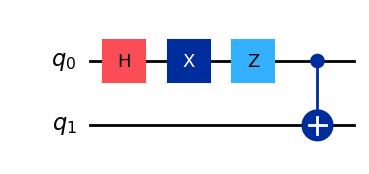

In [ ]:
# Exercício 1: seu código aqui
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)
qc.x(0)
qc.z(0)
qc.cx(0,1)

qc.draw("mpl")

In [ ]:
# Exercício 2: seu código aqui
qc = QuantumCircuit(1)
qc.h(0)
qc.h(0)
qc.h(0)

Statevector.from_instruction(qc)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


{'11': 1024}


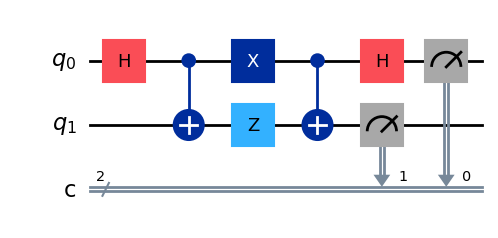

In [ ]:
# Exercício 3: seu código aqui

# Alice aplica Z antes de X
qc.z(0)
qc.x(0)


qc = QuantumCircuit(2, 2)

# Bob prepara |Ψ+>
qc.h(0)
qc.cx(0, 1)
qc.x(0)

# Alice codifica a mensagem "10"
qc.z(1)

# Bob decodifica supondo que o estado inicial era |Φ+>
qc.cx(0, 1)
qc.h(0)

qc.measure([0,1], [0,1])

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()

print(result.get_counts())
qc.draw("mpl")

## Resumo da aula

- A porta **Hadamard** cria superposição e é sua própria inversa ($H^2=I$), uma manifestação direta da unitariedade da evolução quântica.
- Fases relativas (como o sinal em $|-\rangle$) não aparecem nas probabilidades de medição direta, mas afetam o comportamento sob interferência.
- O par **H + CNOT** gera o estado de Bell $|\Phi^+\rangle$; combinado com $X$ e/ou $Z$ em um dos qubits, gera os quatro estados de Bell, uma base completa de estados maximamente emaranhados.
- Estados emaranhados **não se fatoram** em estados individuais e produzem correlações de medição mais fortes que qualquer estado clássico ou produto poderia produzir.
- **Superdense Coding** transforma emaranhamento pré-compartilhado + envio de 1 qubit em transmissão de 2 bits clássicos, ilustrando o emaranhamento como recurso computacional/comunicacional.